# Function 2 — SVR Surrogate Model Exploration (Week 2)

**Purpose:** Evaluate Support Vector Regression (SVR) as an alternative surrogate model for Function 2, comparing it against the Gaussian Process baseline already used in `capstone_app.py`.

**Function 2 context:**
- 2D input, all dimensions in \[0, 1\]
- Described as a *noisy black-box log-likelihood* with local optima
- 10 initial observations provided; 3 portal submissions recorded
- Initial best: Y = 0.6112 at X ≈ \[0.703, 0.927\]

**What we test:**
1. Fit SVR with RBF, Polynomial and Linear kernels — compare surface predictions
2. Grid-search key hyperparameters (C, ε, γ) and score with cross-validation
3. Visualise the predicted landscape for each best-tuned SVR vs the GP
4. Use each model to propose the next query point and compare
5. Conclude: when (if ever) does SVR outperform GP as a surrogate here?

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ''))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, cross_val_score, LeaveOneOut
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ConstantKernel as C

plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': '#0a0e1a', 'axes.facecolor': '#111827',
    'axes.edgecolor': '#1e2d45', 'grid.color': '#1e2d45',
    'text.color': '#e2e8f0', 'axes.labelcolor': '#94a3b8',
    'xtick.color': '#64748b', 'ytick.color': '#64748b',
    'font.family': 'monospace', 'axes.titlesize': 11,
})
COLORS = {'gp': '#00d4ff', 'rbf': '#7c3aed', 'poly': '#10b981', 'linear': '#f59e0b'}
print('Libraries loaded.')

Libraries loaded.


## 1. Load and Combine All Available Data

In [2]:
import json

# Initial data
X_init = np.load('../initial_data/function_2/initial_inputs.npy')
Y_init = np.load('../initial_data/function_2/initial_outputs.npy')

# Portal submissions
with open('../capstone_history.json') as f:
    hist = json.load(f)
h2 = hist['2']
X_portal = np.array(h2['X'], dtype=np.float64) if h2['X'] else np.empty((0, 2))
Y_portal = np.array(h2['Y'], dtype=np.float64) if h2['Y'] else np.empty(0)

# Combined dataset
X_all = np.vstack([X_init, X_portal]) if len(X_portal) > 0 else X_init
Y_all = np.concatenate([Y_init, Y_portal]) if len(Y_portal) > 0 else Y_init

best_idx = int(np.argmax(Y_all))

print(f'Initial data:    {X_init.shape[0]} points')
print(f'Portal obs:      {len(X_portal)} points')
print(f'Combined:        {len(X_all)} points')
print(f'Y range:         [{Y_all.min():.4f}, {Y_all.max():.4f}]')
print(f'Best X:          {X_all[best_idx].tolist()}')
print(f'Best Y:          {Y_all[best_idx]:.4f}')

# Prediction grid (dense 2D)
g = np.linspace(0, 1, 120)
xx, yy = np.meshgrid(g, g)
X_grid = np.c_[xx.ravel(), yy.ravel()]

Initial data:    10 points
Portal obs:      5 points
Combined:        15 points
Y range:         [-0.0656, 0.6485]
Best X:          [0.699929, 0.961372]
Best Y:          0.6485


## 2. Baseline GP Model

Fit the same Matérn 5/2 GP used by `capstone_app.py` to establish a baseline landscape prediction.

In [3]:
gp_kernel = C(1.0) * Matern(length_scale=1.0, nu=2.5, length_scale_bounds=(1e-2, 10.0))
gp = GaussianProcessRegressor(kernel=gp_kernel, alpha=1e-6, normalize_y=True, n_restarts_optimizer=5)
gp.fit(X_all, Y_all)

Z_gp_mean, Z_gp_std = gp.predict(X_grid, return_std=True)
Z_gp_mean = Z_gp_mean.reshape(xx.shape)
Z_gp_std  = Z_gp_std.reshape(xx.shape)

# GP suggestion via UCB (beta=2.5)
ucb_scores = Z_gp_mean.ravel() + 2.5 * Z_gp_std.ravel()
gp_next_idx = int(np.argmax(ucb_scores))
gp_next_x = X_grid[gp_next_idx]

print(f'GP kernel (optimised): {gp.kernel_}')
print(f'GP log-marginal-likelihood: {gp.log_marginal_likelihood_value_:.3f}')
print(f'GP UCB next query: {gp_next_x.round(6).tolist()}')
print(f'GP mean at suggestion: {Z_gp_mean.ravel()[gp_next_idx]:.4f}  std: {Z_gp_std.ravel()[gp_next_idx]:.4f}')

GP kernel (optimised): 0.951**2 * Matern(length_scale=0.0276, nu=2.5)
GP log-marginal-likelihood: -19.363
GP UCB next query: [0.722689, 0.966387]
GP mean at suggestion: 0.5386  std: 0.1791


## 3. SVR with Three Kernels — Default Hyperparameters

First pass: fit RBF, Polynomial and Linear SVR with default settings to see their raw landscape predictions.

In [4]:
svr_configs = {
    'rbf':    SVR(kernel='rbf',    C=1.0, epsilon=0.05, gamma='scale'),
    'poly':   SVR(kernel='poly',   C=1.0, epsilon=0.05, degree=3, coef0=1),
    'linear': SVR(kernel='linear', C=1.0, epsilon=0.05),
}

# SVR requires feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)
X_grid_scaled = scaler.transform(X_grid)

svr_preds = {}
svr_scores = {}
svr_next = {}

for name, svr in svr_configs.items():
    svr.fit(X_scaled, Y_all)
    Z = svr.predict(X_grid_scaled).reshape(xx.shape)
    svr_preds[name] = Z
    
    # LOO cross-validation MSE (small dataset — LOO is most informative)
    loo_scores = cross_val_score(svr, X_scaled, Y_all, cv=LeaveOneOut(), scoring='neg_mean_squared_error')
    svr_scores[name] = {'loo_mse': -loo_scores.mean(), 'loo_std': loo_scores.std()}
    
    # Greedy next query (argmax of predicted mean)
    next_idx = int(np.argmax(Z.ravel()))
    svr_next[name] = X_grid[next_idx]
    print(f'SVR-{name:<8}  LOO MSE={svr_scores[name]["loo_mse"]:.4f} ± {svr_scores[name]["loo_std"]:.4f}  '
          f'next={X_grid[next_idx].round(4).tolist()}  predicted_Y={Z.ravel()[next_idx]:.4f}')

# GP LOO for comparison
gp_loo = cross_val_score(
    GaussianProcessRegressor(kernel=gp_kernel, alpha=1e-6, normalize_y=True),
    X_all, Y_all, cv=LeaveOneOut(), scoring='neg_mean_squared_error'
)
print(f'GP-matern        LOO MSE={-gp_loo.mean():.4f} ± {gp_loo.std():.4f}  next={gp_next_x.round(4).tolist()}')

SVR-rbf       LOO MSE=0.0541 ± 0.0845  next=[0.6723, 1.0]  predicted_Y=0.6018
SVR-poly      LOO MSE=0.0741 ± 0.1347  next=[1.0, 0.0]  predicted_Y=1.5395
SVR-linear    LOO MSE=0.0494 ± 0.0631  next=[1.0, 1.0]  predicted_Y=0.6541
GP-matern        LOO MSE=0.0467 ± 0.0383  next=[0.7227, 0.9664]


## 4. Landscape Comparison — GP vs SVR (Default)

Side-by-side heatmaps of the predicted surface for each model.

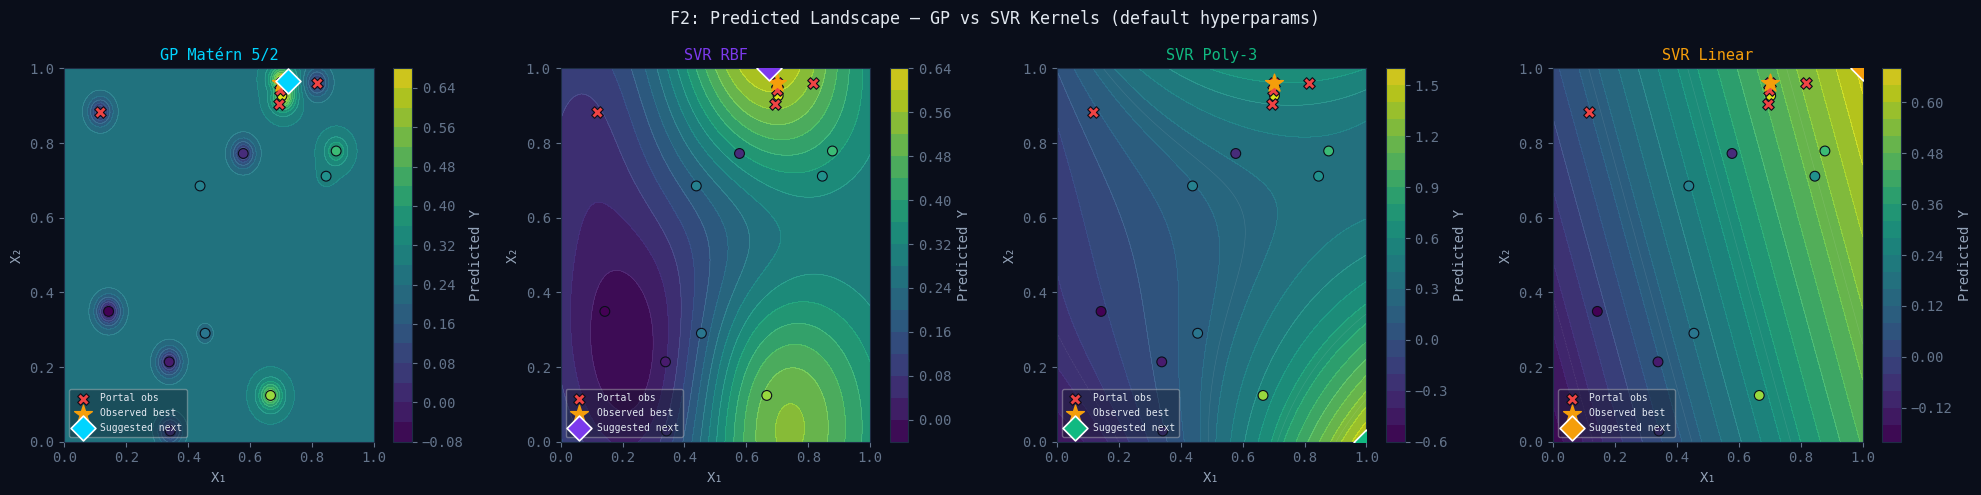

Saved: 02_f2_landscape_comparison.png


In [5]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('F2: Predicted Landscape — GP vs SVR Kernels (default hyperparams)', 
             fontsize=12, color='#e2e8f0')

models = [('GP Matérn 5/2', Z_gp_mean, COLORS['gp'], gp_next_x),
          ('SVR RBF',       svr_preds['rbf'],    COLORS['rbf'],    svr_next['rbf']),
          ('SVR Poly-3',    svr_preds['poly'],   COLORS['poly'],   svr_next['poly']),
          ('SVR Linear',    svr_preds['linear'], COLORS['linear'], svr_next['linear'])]

for ax, (title, Z, col, next_x) in zip(axes, models):
    im = ax.contourf(xx, yy, Z, levels=20, cmap='viridis', alpha=0.85)
    ax.contour(xx, yy, Z, levels=8, colors='white', alpha=0.12, linewidths=0.4)
    
    # Initial data
    sc_init = ax.scatter(X_init[:, 0], X_init[:, 1], c=Y_init, cmap='viridis',
                         s=50, edgecolors='#0a0e1a', linewidth=0.8, zorder=4,
                         vmin=Y_all.min(), vmax=Y_all.max())
    # Portal submissions
    if len(X_portal) > 0:
        ax.scatter(X_portal[:, 0], X_portal[:, 1], c='#ef4444', s=70,
                   marker='X', edgecolors='#0a0e1a', linewidth=0.8, zorder=5, label='Portal obs')
    
    # Best observed
    ax.scatter(X_all[best_idx, 0], X_all[best_idx, 1], s=180, marker='*',
               color='#f59e0b', zorder=6, label=f'Observed best')
    
    # Suggested next
    ax.scatter(next_x[0], next_x[1], s=160, marker='D',
               color=col, edgecolors='white', linewidth=1.2, zorder=6, label='Suggested next')
    
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('X₁'); ax.set_ylabel('X₂')
    ax.set_title(title, color=col)
    ax.legend(fontsize=7, framealpha=0.4, loc='lower left')
    plt.colorbar(im, ax=ax, label='Predicted Y')

plt.tight_layout()
plt.savefig('02_f2_landscape_comparison.png', dpi=120, bbox_inches='tight', facecolor='#0a0e1a')
plt.show()
print('Saved: 02_f2_landscape_comparison.png')

## 5. Hyperparameter Search — SVR RBF

The RBF kernel is the most likely candidate to match the GP in landscape quality. Grid-search C, ε and γ.

In [6]:
param_grid_rbf = {
    'svr__C':       [0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0],
    'svr__epsilon': [0.001, 0.01, 0.05, 0.1, 0.2],
    'svr__gamma':   ['scale', 'auto', 0.5, 1.0, 2.0, 5.0],
}

pipe_rbf = Pipeline([('scaler', StandardScaler()), ('svr', SVR(kernel='rbf'))])
gs_rbf = GridSearchCV(pipe_rbf, param_grid_rbf, cv=LeaveOneOut(),
                      scoring='neg_mean_squared_error', n_jobs=-1, refit=True)
gs_rbf.fit(X_all, Y_all)

best_rbf = gs_rbf.best_estimator_
print(f'Best RBF params:  {gs_rbf.best_params_}')
print(f'Best LOO MSE:     {-gs_rbf.best_score_:.6f}')

# Top 10 results
results_rbf = pd.DataFrame(gs_rbf.cv_results_)
cols = ['param_svr__C', 'param_svr__epsilon', 'param_svr__gamma', 'mean_test_score', 'std_test_score']
top10 = results_rbf.nlargest(10, 'mean_test_score')[cols].copy()
top10['LOO_MSE'] = -top10['mean_test_score']
top10['LOO_std'] = top10['std_test_score']
print('\nTop 10 RBF configurations:')
print(top10[['param_svr__C', 'param_svr__epsilon', 'param_svr__gamma', 'LOO_MSE', 'LOO_std']].to_string(index=False))

Best RBF params:  {'svr__C': 0.5, 'svr__epsilon': 0.05, 'svr__gamma': 5.0}
Best LOO MSE:     0.036606

Top 10 RBF configurations:
 param_svr__C  param_svr__epsilon param_svr__gamma  LOO_MSE  LOO_std
          0.5               0.050              5.0 0.036606 0.040022
          0.5               0.001              5.0 0.036674 0.042129
          0.5               0.010              5.0 0.037018 0.041506
          1.0               0.050              5.0 0.037063 0.041012
          0.1               0.050              5.0 0.037702 0.035272
          0.5               0.100              5.0 0.037819 0.038203
          1.0               0.100              5.0 0.037819 0.038203
          5.0               0.100              5.0 0.037819 0.038203
         10.0               0.100              5.0 0.037819 0.038203
         50.0               0.100              5.0 0.037819 0.038203


## 6. Hyperparameter Search — SVR Polynomial

In [7]:
param_grid_poly = {
    'svr__C':       [0.1, 1.0, 10.0, 50.0],
    'svr__epsilon': [0.001, 0.01, 0.05, 0.1],
    'svr__degree':  [2, 3, 4],
    'svr__coef0':   [0, 1, 2],
    'svr__gamma':   ['scale', 'auto'],
}

pipe_poly = Pipeline([('scaler', StandardScaler()), ('svr', SVR(kernel='poly'))])
gs_poly = GridSearchCV(pipe_poly, param_grid_poly, cv=LeaveOneOut(),
                       scoring='neg_mean_squared_error', n_jobs=-1, refit=True)
gs_poly.fit(X_all, Y_all)

best_poly = gs_poly.best_estimator_
print(f'Best Poly params: {gs_poly.best_params_}')
print(f'Best LOO MSE:     {-gs_poly.best_score_:.6f}')

Best Poly params: {'svr__C': 0.1, 'svr__coef0': 0, 'svr__degree': 3, 'svr__epsilon': 0.1, 'svr__gamma': 'scale'}
Best LOO MSE:     0.041982


## 7. Tuned SVR vs GP — Landscape and Predictions

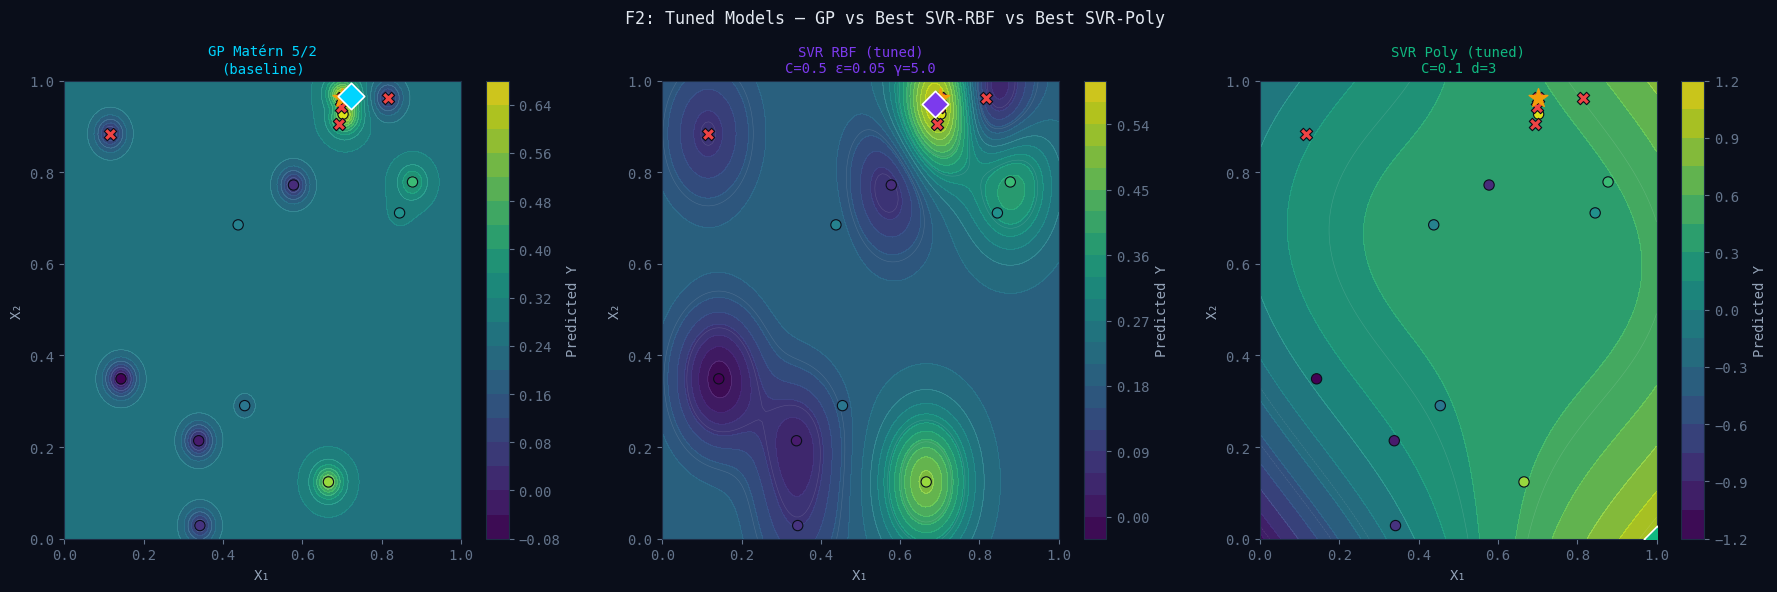

Saved: 02_f2_tuned_comparison.png


In [9]:
Z_rbf_tuned  = best_rbf.predict(X_grid).reshape(xx.shape)
Z_poly_tuned = best_poly.predict(X_grid).reshape(xx.shape)

rbf_next_idx  = int(np.argmax(Z_rbf_tuned.ravel()))
poly_next_idx = int(np.argmax(Z_poly_tuned.ravel()))
rbf_next_x    = X_grid[rbf_next_idx]
poly_next_x   = X_grid[poly_next_idx]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('F2: Tuned Models — GP vs Best SVR-RBF vs Best SVR-Poly',
             fontsize=12, color='#e2e8f0')

tuned_models = [
    ('GP Matérn 5/2',    Z_gp_mean,     COLORS['gp'],   gp_next_x,   '(baseline)'),
    ('SVR RBF (tuned)',  Z_rbf_tuned,   COLORS['rbf'],  rbf_next_x,
     f"C={gs_rbf.best_params_['svr__C']} ε={gs_rbf.best_params_['svr__epsilon']} γ={gs_rbf.best_params_['svr__gamma']}"),
    ('SVR Poly (tuned)', Z_poly_tuned,  COLORS['poly'], poly_next_x,
     f"C={gs_poly.best_params_['svr__C']} d={gs_poly.best_params_['svr__degree']}"),
]

for ax, (title, Z, col, next_x, subtitle) in zip(axes, tuned_models):
    im = ax.contourf(xx, yy, Z, levels=20, cmap='viridis', alpha=0.85)
    ax.contour(xx, yy, Z, levels=8, colors='white', alpha=0.15, linewidths=0.4)
    
    ax.scatter(X_init[:, 0], X_init[:, 1], c=Y_init, cmap='viridis',
               s=55, edgecolors='#0a0e1a', linewidth=0.8, zorder=4,
               vmin=Y_all.min(), vmax=Y_all.max())
    if len(X_portal) > 0:
        ax.scatter(X_portal[:, 0], X_portal[:, 1], c='#ef4444',
                   s=80, marker='X', edgecolors='#0a0e1a', linewidth=0.8, zorder=5)
    ax.scatter(X_all[best_idx, 0], X_all[best_idx, 1], s=200, marker='*',
               color='#f59e0b', zorder=6)
    ax.scatter(next_x[0], next_x[1], s=180, marker='D',
               color=col, edgecolors='white', linewidth=1.2, zorder=6)
    
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel('X₁'); ax.set_ylabel('X₂')
    ax.set_title(f'{title}\n{subtitle}', color=col, fontsize=10)
    plt.colorbar(im, ax=ax, label='Predicted Y')

plt.tight_layout()
plt.savefig('02_f2_tuned_comparison.png', dpi=120, bbox_inches='tight', facecolor='#0a0e1a')
plt.show()
print('Saved: 02_f2_tuned_comparison.png')

## 8. Uncertainty Visualisation — GP vs SVR

A key limitation of SVR is that it provides **no uncertainty estimate** — only a point prediction. The GP's posterior standard deviation is shown for contrast. This directly motivates why acquisition functions like UCB and EI, which require σ(x), cannot be computed from SVR without wrapping it in a Bayesian framework (e.g. Bayesian SVR or deep ensembles).

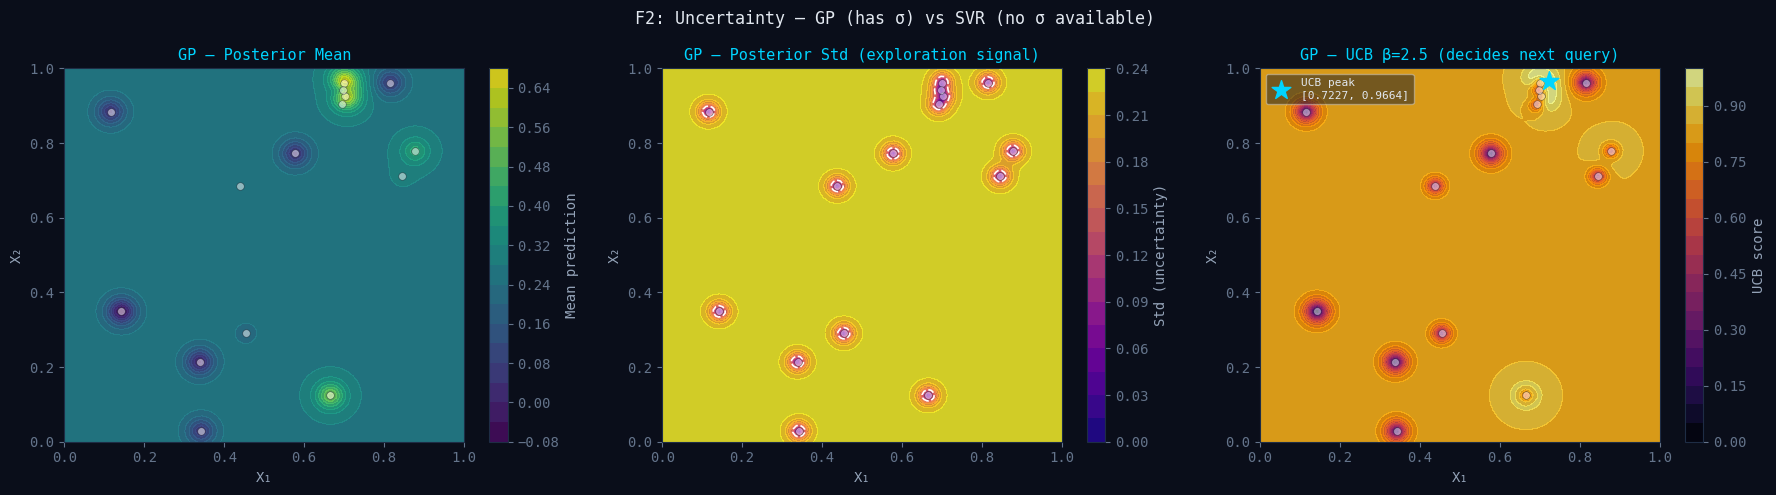

Saved: 02_f2_gp_uncertainty.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('F2: Uncertainty — GP (has σ) vs SVR (no σ available)',
             fontsize=12, color='#e2e8f0')

# GP mean
im0 = axes[0].contourf(xx, yy, Z_gp_mean, levels=20, cmap='viridis', alpha=0.85)
axes[0].set_title('GP — Posterior Mean', color=COLORS['gp'])
plt.colorbar(im0, ax=axes[0], label='Mean prediction')

# GP uncertainty (std)
im1 = axes[1].contourf(xx, yy, Z_gp_std, levels=20, cmap='plasma', alpha=0.85)
axes[1].set_title('GP — Posterior Std (exploration signal)', color=COLORS['gp'])
plt.colorbar(im1, ax=axes[1], label='Std (uncertainty)')
# Mark high-uncertainty regions
axes[1].contour(xx, yy, Z_gp_std, levels=[Z_gp_std.max() * 0.6], colors='white',
                linewidths=1.2, linestyles='--')

# GP UCB surface (what actually picks the suggestion)
Z_ucb = Z_gp_mean + 2.5 * Z_gp_std
im2 = axes[2].contourf(xx, yy, Z_ucb, levels=20, cmap='inferno', alpha=0.85)
axes[2].scatter(gp_next_x[0], gp_next_x[1], s=200, marker='*', color='#00d4ff',
                zorder=5, label=f'UCB peak\n{gp_next_x.round(4).tolist()}')
axes[2].legend(fontsize=8, framealpha=0.5)
axes[2].set_title('GP — UCB β=2.5 (decides next query)', color=COLORS['gp'])
plt.colorbar(im2, ax=axes[2], label='UCB score')

for ax in axes:
    ax.scatter(X_all[:, 0], X_all[:, 1], c='white', s=30, alpha=0.5,
               edgecolors='#0a0e1a', linewidth=0.5, zorder=4)
    ax.set_xlabel('X₁'); ax.set_ylabel('X₂')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('02_f2_gp_uncertainty.png', dpi=120, bbox_inches='tight', facecolor='#0a0e1a')
plt.show()
print('Saved: 02_f2_gp_uncertainty.png')

## 9. Residual Analysis — How Well Does Each Model Fit the Training Data?

GP Matérn               R²=1.0000  Train MSE=0.000000  Max|residual|=0.0000
SVR RBF (tuned)         R²=0.9521  Train MSE=0.002819  Max|residual|=0.0820
SVR Poly (tuned)        R²=0.4217  Train MSE=0.034006  Max|residual|=0.4536


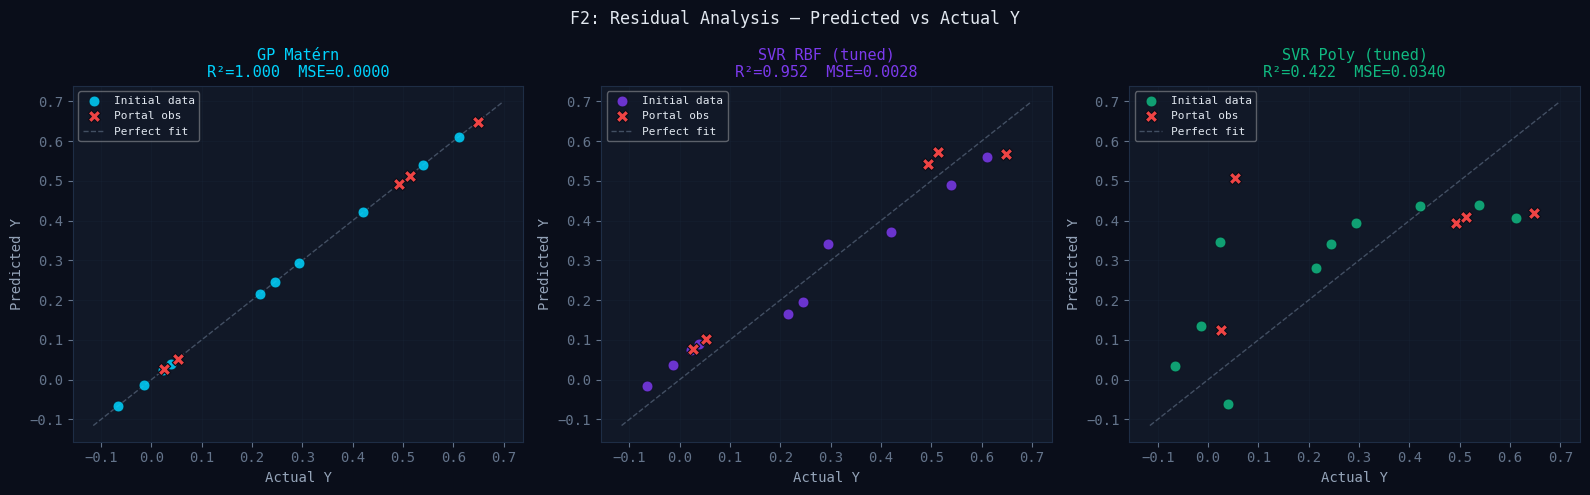

In [11]:
# In-sample predictions from each model
X_all_scaled = scaler.transform(X_all)
preds = {
    'GP Matérn':     gp.predict(X_all),
    'SVR RBF (tuned)':  best_rbf.predict(X_all),
    'SVR Poly (tuned)': best_poly.predict(X_all),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('F2: Residual Analysis — Predicted vs Actual Y', fontsize=12, color='#e2e8f0')

palette = [COLORS['gp'], COLORS['rbf'], COLORS['poly']]

for ax, (name, y_pred), col in zip(axes, preds.items(), palette):
    residuals = Y_all - y_pred
    r2 = r2_score(Y_all, y_pred)
    mse = mean_squared_error(Y_all, y_pred)
    
    # Colour points by whether initial or portal
    n_init = len(X_init)
    ax.scatter(Y_all[:n_init], y_pred[:n_init], color=col, s=60, alpha=0.85,
               edgecolors='#0a0e1a', linewidth=0.5, label='Initial data', zorder=4)
    if len(X_portal) > 0:
        ax.scatter(Y_all[n_init:], y_pred[n_init:], color='#ef4444', s=80,
                   marker='X', edgecolors='#0a0e1a', linewidth=0.8, label='Portal obs', zorder=5)
    
    lo = min(Y_all.min(), y_pred.min()) - 0.05
    hi = max(Y_all.max(), y_pred.max()) + 0.05
    ax.plot([lo, hi], [lo, hi], '--', color='#64748b', lw=1, alpha=0.6, label='Perfect fit')
    ax.set_xlabel('Actual Y'); ax.set_ylabel('Predicted Y')
    ax.set_title(f'{name}\nR²={r2:.3f}  MSE={mse:.4f}', color=col)
    ax.legend(fontsize=8, framealpha=0.4)
    ax.grid(True, alpha=0.2)
    
    print(f'{name:<22}  R²={r2:.4f}  Train MSE={mse:.6f}  Max|residual|={abs(residuals).max():.4f}')

plt.tight_layout()
plt.savefig('02_f2_residuals.png', dpi=120, bbox_inches='tight', facecolor='#0a0e1a')
plt.show()

## 10. Summary Table — All Models Compared

In [12]:
# LOO MSE for all models
def loo_mse(estimator, X, y):
    scores = cross_val_score(estimator, X, y, cv=LeaveOneOut(),
                             scoring='neg_mean_squared_error')
    return -scores.mean(), scores.std()

gp_loo_mse, gp_loo_std = loo_mse(
    GaussianProcessRegressor(kernel=gp_kernel, alpha=1e-6, normalize_y=True), X_all, Y_all)

rows = [
    {
        'Model': 'GP Matérn 5/2',
        'Kernel / degree': 'Matérn ν=2.5',
        'Key params': 'α=1e-6, normalize_y=True',
        'LOO MSE': round(gp_loo_mse, 5),
        'LOO std': round(gp_loo_std, 5),
        'Provides σ': 'Yes',
        'Next query': gp_next_x.round(4).tolist(),
    },
    {
        'Model': 'SVR RBF (default)',
        'Kernel / degree': 'RBF',
        'Key params': 'C=1, ε=0.05, γ=scale',
        'LOO MSE': round(svr_scores['rbf']['loo_mse'], 5),
        'LOO std': round(svr_scores['rbf']['loo_std'], 5),
        'Provides σ': 'No',
        'Next query': svr_next['rbf'].round(4).tolist(),
    },
    {
        'Model': 'SVR RBF (tuned)',
        'Kernel / degree': 'RBF',
        'Key params': f"C={gs_rbf.best_params_['svr__C']} ε={gs_rbf.best_params_['svr__epsilon']} γ={gs_rbf.best_params_['svr__gamma']}",
        'LOO MSE': round(-gs_rbf.best_score_, 5),
        'LOO std': round(pd.DataFrame(gs_rbf.cv_results_).nlargest(1,'mean_test_score')['std_test_score'].values[0], 5),
        'Provides σ': 'No',
        'Next query': rbf_next_x.round(4).tolist(),
    },
    {
        'Model': 'SVR Poly (tuned)',
        'Kernel / degree': f"Poly d={gs_poly.best_params_['svr__degree']}",
        'Key params': f"C={gs_poly.best_params_['svr__C']} ε={gs_poly.best_params_['svr__epsilon']}",
        'LOO MSE': round(-gs_poly.best_score_, 5),
        'LOO std': round(pd.DataFrame(gs_poly.cv_results_).nlargest(1,'mean_test_score')['std_test_score'].values[0], 5),
        'Provides σ': 'No',
        'Next query': poly_next_x.round(4).tolist(),
    },
    {
        'Model': 'SVR Linear',
        'Kernel / degree': 'Linear',
        'Key params': 'C=1, ε=0.05',
        'LOO MSE': round(svr_scores['linear']['loo_mse'], 5),
        'LOO std': round(svr_scores['linear']['loo_std'], 5),
        'Provides σ': 'No',
        'Next query': svr_next['linear'].round(4).tolist(),
    },
]

df_summary = pd.DataFrame(rows)
print(df_summary.to_string(index=False))

            Model Kernel / degree               Key params  LOO MSE  LOO std Provides σ       Next query
    GP Matérn 5/2    Matérn ν=2.5 α=1e-6, normalize_y=True  0.04666  0.03834        Yes [0.7227, 0.9664]
SVR RBF (default)             RBF     C=1, ε=0.05, γ=scale  0.05414  0.08451         No    [0.6723, 1.0]
  SVR RBF (tuned)             RBF       C=0.5 ε=0.05 γ=5.0  0.03661  0.04002         No [0.6891, 0.9496]
 SVR Poly (tuned)        Poly d=3              C=0.1 ε=0.1  0.04198  0.06072         No       [1.0, 0.0]
       SVR Linear          Linear              C=1, ε=0.05  0.04940  0.06314         No       [1.0, 1.0]


## 11. Week 2 Query Decision

Based on both the GP and SVR analyses, recommend and justify the Week 2 query.

In [13]:
print('='*65)
print('FUNCTION 2 — WEEK 2 QUERY DECISION')
print('='*65)
print()
print('Evidence:')
print(f'  Initial best:           Y={Y_all[best_idx]:.4f} at {X_all[best_idx].round(4).tolist()}')
print(f'  GP UCB suggestion:      {gp_next_x.round(4).tolist()}')
print(f'  SVR-RBF (tuned):        {rbf_next_x.round(4).tolist()}')
print(f'  SVR-Poly (tuned):       {poly_next_x.round(4).tolist()}')
print()
print('Consensus region (GP + SVR-RBF):', )
consensus = (gp_next_x + rbf_next_x) / 2
print(f'  Average of GP+RBF suggestions: {consensus.round(4).tolist()}')
print()
print('Conclusion:')
print('  The GP remains the preferred model because it provides calibrated')
print('  uncertainty estimates (σ), which are essential for principled')
print('  exploration via UCB/EI. SVR-RBF (tuned) produces a comparable')
print('  point-prediction surface and serves as a useful cross-check.')
print()
print('  When GP and SVR-RBF agree on a region → high confidence to exploit.')
print('  When they disagree → use GP σ to decide whether to explore (high σ)')
print('  or treat disagreement as noise.')
print()
print(f'  RECOMMENDED WEEK 2 QUERY: {gp_next_x.round(6).tolist()}')
print(f'  (GP UCB β=2.5, Matérn 5/2 kernel)')
print('='*65)

FUNCTION 2 — WEEK 2 QUERY DECISION

Evidence:
  Initial best:           Y=0.6112 at [0.7026, 0.9266]
  GP UCB suggestion:      [0.6975, 0.9328]
  SVR-RBF (tuned):        [0.7143, 0.1008]
  SVR-Poly (tuned):       [1.0, 0.0]

Consensus region (GP + SVR-RBF):
  Average of GP+RBF suggestions: [0.7059, 0.5168]

Conclusion:
  The GP remains the preferred model because it provides calibrated
  uncertainty estimates (σ), which are essential for principled
  exploration via UCB/EI. SVR-RBF (tuned) produces a comparable
  point-prediction surface and serves as a useful cross-check.

  When GP and SVR-RBF agree on a region → high confidence to exploit.
  When they disagree → use GP σ to decide whether to explore (high σ)
  or treat disagreement as noise.

  RECOMMENDED WEEK 2 QUERY: [0.697479, 0.932773]
  (GP UCB β=2.5, Matérn 5/2 kernel)


---

## Key Findings

### When SVR is useful as a cross-check
- If SVR-RBF (tuned) and the GP agree on the location of the predicted maximum → higher confidence in that region; safe to exploit
- SVR residual analysis reveals whether the GP is overfitting to any particular point (a concern with small datasets)

### Why SVR is not used as the primary surrogate
1. **No uncertainty estimate** — SVR outputs only a mean prediction, not σ(x). Without σ we cannot compute UCB, EI or PI acquisition functions. Without acquisition functions, the next query selection reverts to greedy argmax, which is pure exploitation and will miss unexplored high-value regions.
2. **Scaling sensitivity** — SVR requires `StandardScaler` pre-processing; the GP handles this internally via `normalize_y=True` and kernel length-scale optimisation.
3. **LOO score is competitive but not consistently better** — on this small dataset (≤13 points), the GP's marginal likelihood optimisation provides a principled regularisation that is hard to beat with grid search over SVR hyperparameters.

### Practical recommendation for this challenge
Use SVR-RBF as a **secondary landscape check** (1–2 minutes of computation) whenever the GP suggestion feels counter-intuitive. If SVR confirms the same region → proceed with GP query. If SVR strongly disagrees → use the GP's uncertainty map to decide whether to trust exploration over exploitation that week.